# Implied Volatility Surface

In finance, volatility is a measure of how much an asset's returns change over time. Higher volatility means an asset's price moves up and down quickly and steeply, while a lower volatility means the asset's price doesn't change as quickly or steeply. Volatility is usually measured on an annual basis, but can be extended to longer or shorter time frames. Understanding volatility can help us make better decisions in the financial world, especially when it comes to options pricing.

Two important types of volatility are: Historical Volatility, and Implied Volatility.

**Historical Volatility (HV)**

Historical volatility refers to the past volatility that an asset experienced. Historical volatility can be calculated by finding the annualized standard deviation of historical log returns. Here's how to do that:

Given a sequence of closing prices

$$
P_0, P_1, P_2, \ldots, P_n,
$$

the continuously compounded (log) return for day $i$ is

$$
r_i=\ln\left(\frac{P_i}{P_{i-1}}\right),
\qquad i=1,\ldots,n.
$$

The mean log return is

$$
\bar{r}
=
\frac{1}{n}
\sum_{i=1}^{n} r_i.
$$

The sample standard deviation of the log returns is

$$
\sigma_{\text{daily}}
=
\sqrt{
\frac{1}{n-1}
\sum_{i=1}^{n}
\left(r_i-\bar{r}\right)^2
}.
$$

The annualized historical volatility is

$$
\sigma_{\text{HV}}
=
\sigma_{\text{daily}}
\sqrt{252},
$$

where 252 is the approximate number of trading days in a year.

HV tells us how an asset behaved in the past, but what if we want to know how it will behave in the future?

**Implied Volatility**

Implied volatility is the market's estimate of the future volatility of an underlying asset. For options, it is the expected volatility over the lifetime of the option.
Unfortunately, historical volatility and the methods used to find it are not very useful when trying to infer the future volatility of an asset. Past volatility is not indicative of future volatility, so we'll need a different strategy.

A very revolutionary tool used to deduce the implied volatility is the Black-Scholes equation. The equation was published by Fischer Black and Myron Scholes in 1973 and is used to deduce the fair price of options under simplifying assumptions.

<div style="text-align: center;">
  <strong>Black-Scholes PDE</strong>
</div>                                        
$$
\frac{\partial V}{\partial t}
+ \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
+ rS\frac{\partial V}{\partial S}
- rV = 0.
$$
where

- $V(S,t)$ : Value of the derivative as a function of asset price and time
- $S$ : Current price of the underlying asset
- $t$ : Current time before expiration
- $\sigma$ : Volatility of the underlying asset during the option's lifetime
- $r$ : Continuously compounded risk-free interest rate 
- $\frac{\partial V}{\partial t}$ : Sensitivity of the option value to time
- $\frac{\partial V}{\partial S}$ : First derivative of the option value with respect to the asset price (Delta)
- $\frac{\partial^2 V}{\partial S^2}$ : Second derivative of the option value with respect to the asset price (Gamma)

In practice, computing with the PDE version is relatively slow, so let's change it into a closed-form version.

**First**, we need to assume that the underlying asset follows geometric brownian motion. 
$$dS = \mu S\,dt + \sigma S\,dW_t$$
where 

- $
\mu S\,dt
$   : Is the drift term (average growth rate), and
 
- $
\sigma S\,dW_t
$   : Is the random shock term (unpredictable noise)

This allows us to treat the Black-Scholes model as a stochastic one

**Second**, we apply Itô's Lemma to the option price $V(S,t)$,
assuming $V = V(S,t)$

Itô's Lemma gives:
$$
dV = V_t dt + V_s dS +\frac{1}{2} V_{ss}(dS)^2
$$
where

$
V_{SS} = \frac{\partial^2 V}{\partial S^2}
$


Now we can substitute 

$dS = \mu S\,dt + \sigma S\,dW$

$(dW)^2 = dt$


So: 
$$
dV = (V_t +\mu S\,V_s + \frac{1}{2}\sigma^2 S^2 V_{ss})dt + \sigma S\,V_s dW
$$


**Third**, we build a hedged portfolio to eliminate risk

We have a portfolio:
$$\Pi = V - \Delta S$$

where $V$ is the option price, $\Delta$ is the number of shares held short and $S$ is the stock price.

Taking the differential:

$$
d\Pi = dV - \Delta dS
$$

Substitute $dV$ and $dS$:

$$
d\Pi =
\left(
V_t + \mu S V_S + \frac{1}{2}\sigma^2 S^2 V_{SS}
\right)dt
+ \sigma S V_S dW
- \Delta (\mu S dt + \sigma S dW)
$$

and choose

$$
\Delta = V_S
$$

so that the random term $dW$ cancels. 

Now we have:

$$
d\Pi = (V_t + \frac{1}{2}\sigma^2S^2V_{ss})dt
$$

Notice how the drift component $\mu$ and random component $dW$ are gone?
This means all risk is removed, making the portfolio deterministic.




**Fourth**, now that the portfolio $\Pi$ is risk free, it must grow at the risk free rate $r$.

So:
$$
d\Pi = r \Pi\, dt
$$

and 
$$
d\Pi = r(V - SV_s)dt
$$


We can equate both expressions

$$
V_t + \frac{1}{2}\sigma^2S^2V_{ss} = rV - rSV_s
$$

Rearrange

$$
V_t + \frac{1}{2}\sigma^2S^2V_{ss} + rSV_s - rV = 0
$$



**Fifth**, we anchor the PDE with $V(S,t) = max(S - K,0)$ at expiry (European call), and solve the PDE to obtain the closed form:
$$
C = N(d_+) S_t - N(d_-)Ke^{-rt}
$$

with

$
d_+ = \frac{ln(\frac{S_t}{K}) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}
$
,

$
d_- = d_+ - \sigma\sqrt{T}
$

and

$N$ being the cumulative distribution function (basically the area under the distribution up to d).


In this equation, we already have the:
- options's price which is dictated by supply and demand
- underlying asset price
- strike price
- time to expiration
- risk free rate dictated by treasuries or bonds

All that we are missing is the volatility; we know exactly what to do when we have one equation and one unknown.
Wait, there are no operations that we can perform to isolate $\sigma$, so the best way is to use numerical methods to find the $\sigma$ value that minimizes the difference between the given option price and the calculated option price.

This is why it is called implied volatility. We are solving for the volatility value that is implied by the market, meaning the volatility that makes the Black–Scholes price match the observed market price.

**Implied Volatility Surface**

The implied volatility surface is a visual representation of the volatilities that allow the Black-Scholes price to match the market price at varying strikes and maturities. This surface can reveal a lot of information about the underlying asset. It can show us the market expectations and what investors are worried about

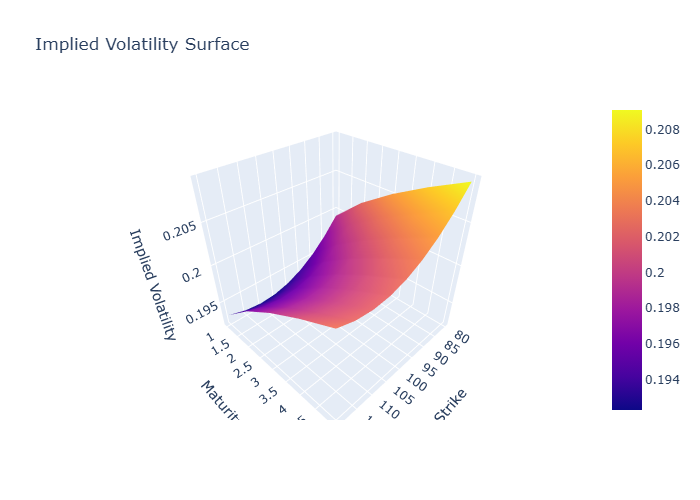

In [2]:
import numpy as np
import yfinance as yf
import scipy.stats as sc
import plotly.io as pio
import datetime
pio.renderers.default = "png"
import plotly.graph_objects as go

from scipy.optimize import brentq


def Black_Scholes_Call(S_t, K, r, T, sigma):

    d_p = (np.log(S_t/K) + (r + (sigma**2)/2)*(T))/(sigma*np.sqrt(T))

    d_m = d_p - sigma*np.sqrt(T)

    C = sc.norm.cdf(d_p)*S_t - sc.norm.cdf(d_m)*K*np.exp((-r)*(T))

    return C


def implied_volatility(C, S, K, r, T):

    def objective(sigma):
        return Black_Scholes_Call(S, K, r, T, sigma) - C

    implied_vol = brentq(
        objective,
        0.01,
        5
    )

    return implied_vol

# ---- ChatGPT Data Generation ----    

data = []

S = 100
r = 0.04

for T in range(1, 6):
    for K in range(80, 121, 5):

        moneyness = (K - S) / S

        sigma = (
            0.185
            + 0.08 * moneyness**2          # smile centered at ATM
            + 0.015 * (-moneyness)         # slight equity skew
            + 0.008 * np.sqrt(T)            # maturity effect
        )

        price = Black_Scholes_Call(
            S,
            K,
            r,
            T,
            sigma
        )

        data.append(
            (S, K, float(T), r, price)
        )
#--------------------------------

def implied_vol_surface(d):

    strikes = np.array([t[1] for t in d])
    maturities = np.array([t[2] for t in d])
    iv = np.array([implied_volatility(t[4], t[0], t[1], t[3], t[2]) for t in d])

    uniq_strikes = np.unique(strikes)
    uniq_maturities = np.unique(maturities)

    S_grid = np.zeros((len(uniq_maturities), len(uniq_strikes)))
    T_grid = np.zeros((len(uniq_maturities), len(uniq_strikes)))
    IV_grid = np.zeros((len(uniq_maturities), len(uniq_strikes)))

    for i, T in enumerate(uniq_maturities):
        for j, K in enumerate(uniq_strikes):
            mask = (maturities == T) & (strikes == K)
            S_grid[i, j] = K
            T_grid[i, j] = T
            IV_grid[i, j] = iv[mask][0]
                
                      
    fig = go.Figure(data=[go.Surface(x=S_grid, y=T_grid, z=IV_grid)])

    fig.update_layout(
        title='Implied Volatility Surface',
        scene=dict(
            xaxis_title='Strike',
            yaxis_title='Maturity',
            zaxis_title='Implied Volatility'
        )
    )

    fig.show()

implied_vol_surface(data)

**Implied Volatility Surface**

The implied volatility surface is a visual representation of the volatilities that allow the Black-Scholes price to match the market price at varying strikes and maturities. This surface can reveal a lot of information about the underlying asset. It can show us the market expectations and what investors are worried about. For example, with S&P 500 options, the implied volatility on OTM puts is highest. This is because investors are willing to pay more for downside protection, and higher price translates to higher IV. In contrast, for commodity options, the implied volatility is highest for OTM calls because investors want protection from rising prices. The IV surface is also useful for identifying mispricings by allowing a trader to easily compare options' implied volatilities.


**Problems with the Black-Scholes Model**

The Black-Scholes model relies on several simplifying assumptions about financial markets. While these assumptions make the model mathematically simpler, many do not hold in the real world, leading to differences between theoretical option prices and observed market prices. These limitations help explain why the Black-Scholes model should not be used to directly price options.

**- Assumption 1: Constant Volatility**
    
In real markets, volatility changes over time rather than remaining constant. 

Volatility depends on the strike price (volatility smile/skew). As shown in the above figure, volatility is higher for strikes that are further away from the underlying price. This makes sense because there is more uncertainty about their payoffs.

Volatility depends on the time until expiration. Because stock prices change over time, time has a large effect on the probability of the option expiring ITM. If an option has a shorter time to expiration, it has less of a chance of having a large price swing, which converts to a lower volatility. For options with a longer time until maturity, the volatility is higher because there is a higher chance of a large price swing. 

As we know, implied volatility surfaces are not flat. If market options prices were quoted based on the Black-Scholes model, which assumes constant volatility, the implied volatility surface would be a flat plane. This would create all sorts of problems, including a free money printer for the other party.

Pretend we are an options desk that assumes a constant $\sigma$ of 20%. For strikes of 80 dollars, investors are willing to pay a premium for downside protection, since the put acts as insurance. This is also shown in the skew with the strike of 80 dollars having the highest implied volatility. The investor could notice that our quote is underpriced and buy our options. The buyer then can profit in two ways. First, if the market recognizes the mispricing and the option price increases to reach equilibrium, then the buyer can sell the contracts and gain the difference. Second, the buyer can continuously rebalance a hedge position in the underlying asset to offset market movements. If the realized volatility is higher than the implied volatility, the gains from the hedge exceed the option's time decay, and the buyer can profit. 

Over time, these mispricings can slowly bleed out the seller's account by providing the buyer with systematic opportunities for arbitrage.


**- Assumption 2: Stock prices follow a lognormal distribution**

A lognormal distribution assumes that stock prices are lognormally distributed, meaning that the logarithm of the stock price ratio $\frac{S_t}{S_0}$, known as the continuously compounded return, follows a normal distribution. This is descibed mathematically as:

$$
ln(\frac{S_t}{S_0})  ∼  N((\mu-\frac{1}{2}\sigma^2)T, \sigma^2T)
$$

where the $∼N(mean,variance)$ means the returns follow a normal distribution with a specific mean and variance.


Rare stock returns happen a lot more often than the lognormal distribution would estimate. This is referred to as fat-tails. On a lognormal distribution, a 5% drop in the S&P 500 would happen once every 100 years, but in reality, it happens several times per decade. If an options desk assumed a lognormal distribution, their OTM options (especially puts) would be severely underpriced.

Markets have a lot more large negative movements than equally large upward movements, which leads to a larger left tail of the distribution. 

Periods of high volatility are often followed by high volatility, and periods of low volatility are often followed by low volatility. This happens because the market has memory. The lognormal distribution of returns implies that every return is independent, which is incorrect.

Return distributions change over time, which is referred to as non-stationarity . The lognormal model assumes that the same distribution applies to an asset forever, but in reality, it changes due to many factors. These factors include: changing interest rates, investors sentiment, geopolitical events, etc. 

The Black-Scholes framework assumes that stock returns follow a stable random process, but this assumption breaks down during extreme economic events. This is another area where return distributions change and the downside tail grows.

**Other Assumptions**
If the above interests you, here are some other assumptions that you can check out:
-continuous stock price movements
-continuous hedging
-constant risk free rate


# Conclusion
Understanding the implied volatility surface is a valuable tool that gives a solid estimate for the volatility of an asset in the near future. Any mispricing can be exploited by a knowledgeable trader and slowly eat away one's account. The Black-Scholes framework is extremely useful for options pricing, but one must understand its limitations to apply it effectively. I hope this work enhances the reader's understanding of options and options pricing, the Black-Scholes model and its applications, as well as its limitations. Now, if you ever lose exorbitant amounts of money trading options, remember: this is not financial advice.
